Найдено CpG-островков: 5
  [  79566 –   81018],  длина=1452
  [  81820 –   82055],  длина=235
  [  82088 –   82394],  длина=306
  [  82554 –   84271],  длина=1717
  [  84409 –   86682],  длина=2273


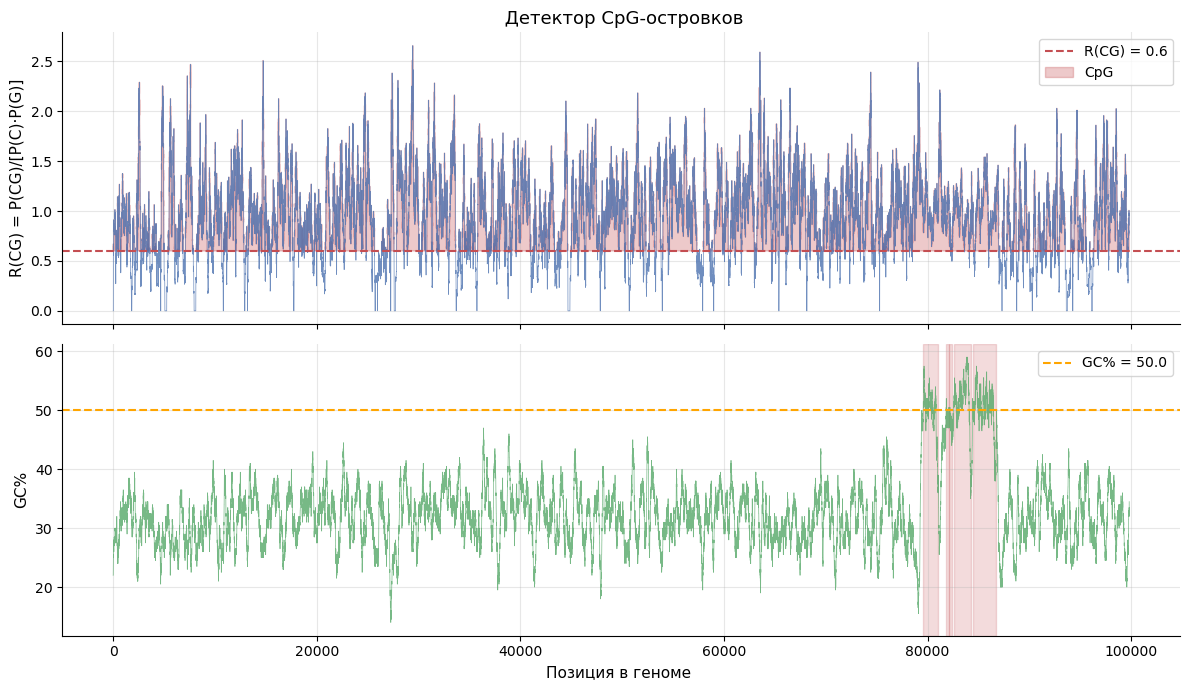

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
 
NUCLEOTIDES = ["A", "C", "G", "T"]
NUC2IDX     = {n: i for i, n in enumerate(NUCLEOTIDES)}
FASTA_PATH  = "436.fasta.fa"
seq_parts = []
with open(FASTA_PATH) as f:
    for line in f:
        line = line.strip()
        if not line.startswith(">"):
            seq_parts.append(line.upper())
seq = "".join(seq_parts)
dinuc = np.zeros((4,4), dtype=int)
for k in range(len(seq)-1):
    a, b = seq[k], seq[k+1]
    if a in NUC2IDX and b in NUC2IDX:
        dinuc[NUC2IDX[a], NUC2IDX[b]] += 1
P = dinuc / dinuc.sum(axis=1, keepdims=True)
evals, evecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(evals - 1.0))
pi  = evecs[:, idx].real; pi /= pi.sum()

REGION    = seq[:100_000]
WIN       = 200
STEP      = 1
R_THRESH  = 0.6
GC_THRESH = 50.0
 
def compute_cpg_ratio(window):
    n   = len(window)
    cg  = sum(1 for i in range(n-1) if window[i]=="C" and window[i+1]=="G") / max(n-1, 1)
    pc  = window.count("C") / n
    pg  = window.count("G") / n
    gc  = (window.count("G") + window.count("C")) / n * 100
    r   = cg / (pc * pg) if pc > 0 and pg > 0 else 0.0
    return cg, pc, pg, r, gc
 
positions, r_values, gc_values = [], [], []
for start in range(0, len(REGION) - WIN + 1, STEP):
    w = REGION[start:start + WIN]
    _, _, _, r, gc = compute_cpg_ratio(w)
    positions.append(start)
    r_values.append(r)
    gc_values.append(gc)
 
positions  = np.array(positions)
r_values   = np.array(r_values)
gc_values  = np.array(gc_values)
cpg_mask    = (r_values > R_THRESH) & (gc_values > GC_THRESH)
cpg_hits    = positions[cpg_mask]
islands = []
if len(cpg_hits) > 0:
    start_isl = cpg_hits[0]
    prev      = cpg_hits[0]
    for pos in cpg_hits[1:]:
        if pos - prev > WIN:
            islands.append((start_isl, prev + WIN))
            start_isl = pos
        prev = pos
    islands.append((start_isl, prev + WIN))
 
print(f"Найдено CpG-островков: {len(islands)}")
for s, e in islands[:20]:
    print(f"  [{s:>7} – {e:>7}],  длина={e-s}")
 
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1 = axes[0]
ax1.plot(positions, r_values, color="#4C72B0", linewidth=0.5, alpha=0.8)
ax1.axhline(R_THRESH, color="#C44E52", linewidth=1.5,
            linestyle="--", label=f"R(CG) = {R_THRESH}")
ax1.fill_between(positions, r_values, R_THRESH,
                 where=(r_values > R_THRESH), alpha=0.3,
                 color="#C44E52", label="CpG")
ax1.set_ylabel("R(CG) = P(CG)/[P(C)·P(G)]", fontsize=11)
ax1.set_title(" Детектор CpG-островков", fontsize=13)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax2 = axes[1]
ax2.plot(positions, gc_values, color="#55A868", linewidth=0.5, alpha=0.8)
ax2.axhline(GC_THRESH, color="orange", linewidth=1.5,
            linestyle="--", label=f"GC% = {GC_THRESH}")
for s, e in islands:
    ax2.axvspan(s, e, alpha=0.2, color="#C44E52")
ax2.set_xlabel("Позиция в геноме ", fontsize=11)
ax2.set_ylabel("GC%", fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()